In [78]:
#import libraries

In [77]:
import pandas as pd 
import numpy as np

In [2]:
columns = ['engine_id', 'cycle']

columns += [f'op_setting_{i}' for i in range(1, 4)]

columns += [f'sensor_{i}' for i in range(1, 22)]

len(columns)

26

In [3]:
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

In [4]:
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
train_df['engine_id'].nunique()

100

In [6]:
#So there 100 unique engines are there in dataset as you see the previous output


In [7]:
#using groupedby()

In [8]:
train_df.groupby('engine_id')['cycle'].max().head()

engine_id
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [9]:
rul_df = train_df.groupby('engine_id')['cycle'].max().reset_index()

rul_df.columns = ['engine_id', 'max_cycle']

rul_df.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [13]:
train_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')

In [ ]:
#checking missing values

In [16]:
train_df.isnull().sum()

engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dtype: int64

In [17]:
train_df.shape

(20631, 26)

In [19]:
train_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')

In [20]:
rul_df = train_df.groupby('engine_id')['cycle'].max().reset_index()

rul_df.columns = ['engine_id', 'max_cycle']

rul_df.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [21]:
#merge

In [22]:
train_df = train_df.merge(
    rul_df,
    on='engine_id',
    how='left'
)

In [23]:
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

In [24]:
train_df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycle', 'RUL'],
      dtype='object')

In [25]:
#creating features and target

In [26]:
X = train_df.drop(['RUL', 'max_cycle'], axis=1)

y = train_df['RUL']

In [28]:
X.shape

(20631, 26)

In [29]:
y.shape

(20631,)

In [30]:
#Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size = 0.2,
random_state = 42 
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16504, 26)
(4127, 26)
(16504,)
(4127,)


In [36]:
#linearRegression()

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [39]:
#now predict RUL

In [40]:
y_pred = lr.predict(X_test)

In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 39.228014594512


In [42]:
print("RMSE:", rmse)

RMSE: 39.228014594512


In [43]:
#RandomForest

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 16.108062238570394


In [49]:
#features importance

In [50]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,cycle,0.539696
0,engine_id,0.172310
15,sensor_11,0.134429
13,sensor_9,0.031385
8,sensor_4,0.027871
16,sensor_12,0.019404
18,sensor_14,0.017073
11,sensor_7,0.009688
17,sensor_13,0.007561
19,sensor_15,0.006752


In [51]:
#dropping max_cycle, RUL, engine_id

In [53]:
X = train_df.drop(
    ['RUL', 'max_cycle', 'engine_id'],
    axis=1
)

y = train_df['RUL']

In [54]:
#again train-test-split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
#training random forest

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [58]:
#prediction

In [59]:
rf_pred = rf.predict(X_test)

In [60]:
#RMSE

In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 35.97346672398293


In [63]:
#RMSE with engine_id = 16
#RMSE without engine_id = 36

In [64]:
#using xgboost Algorithm

In [65]:
import xgboost
print(xgboost.__version__)

3.2.0


In [66]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [67]:
#RMSE prediction from applying xgboost

In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("XGBoost RMSE:", xgb_rmse)

XGBoost RMSE: 35.82770674488793


In [69]:
#features importance and sensor analysis

In [70]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
0,cycle,0.476600
14,sensor_11,0.148709
7,sensor_4,0.081148
15,sensor_12,0.046106
12,sensor_9,0.036924
10,sensor_7,0.034150
11,sensor_8,0.022019
17,sensor_14,0.018907
23,sensor_20,0.018870
18,sensor_15,0.018862


In [71]:
train_df[['sensor_11', 'RUL']].corr()

,sensor_11,RUL
sensor_11,1.000000,-0.696228
RUL,-0.696228,1.000000


In [72]:
train_df[['sensor_4', 'RUL']].corr()

,sensor_4,RUL
sensor_4,1.000000,-0.678948
RUL,-0.678948,1.000000


In [73]:
train_df[['sensor_12', 'RUL']].corr()

,sensor_12,RUL
sensor_12,1.000000,0.671983
RUL,0.671983,1.000000


In [74]:
#Visualizations

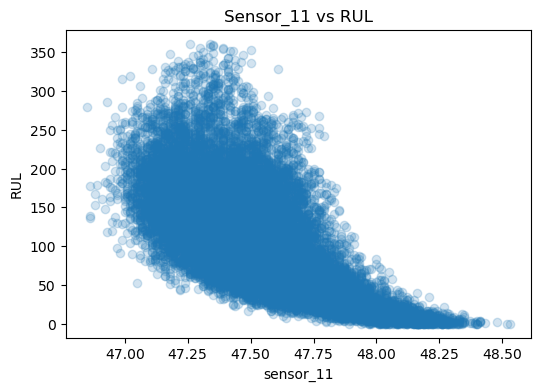

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    train_df['sensor_11'],
    train_df['RUL'],
    alpha=0.2
)

plt.xlabel('sensor_11')
plt.ylabel('RUL')
plt.title('Sensor_11 vs RUL')

plt.show()

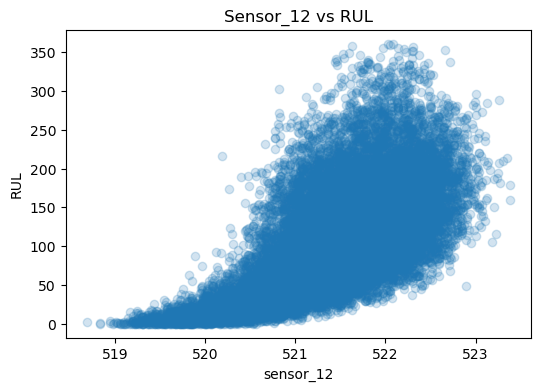

In [82]:
plt.figure(figsize=(6,4))

plt.scatter(
    train_df['sensor_12'],
    train_df['RUL'],
    alpha=0.2
)

plt.xlabel('sensor_12')
plt.ylabel('RUL')
plt.title('Sensor_12 vs RUL')

plt.show()

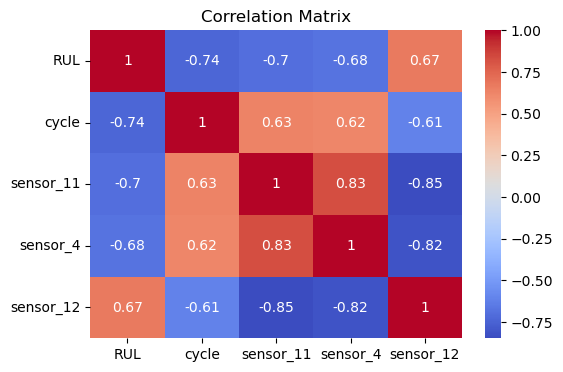

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_features = ['RUL', 'cycle', 'sensor_11', 'sensor_4', 'sensor_12']

plt.figure(figsize=(6,4))
sns.heatmap(
    train_df[corr_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [85]:
import os
os.getcwd()

'C:\\Users\\ASUS\\Predictive_Maintenance'

In [ ]:
# Final Conclusion

## Model Performance

- Linear Regression RMSE: 39.23
- Random Forest RMSE: 35.97
- XGBoost RMSE: 35.83

## Key Findings

- cycle was the most important feature.
- sensor_11 and sensor_4 showed strong negative correlation with RUL.
- sensor_12 showed strong positive correlation with RUL.
- Tree-based models outperformed Linear Regression.
- engine_id was removed because it acted as an identifier and could cause memorization.

## Business Impact

This model can help maintenance teams estimate Remaining Useful Life (RUL) and schedule maintenance before engine failure occurs.